# STEM quickstart


## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [ ]:
import abtem
abtem.config.set(
    {
        "device": "gpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

: 

## Atomic model
We create an orthogonal graphene cell. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

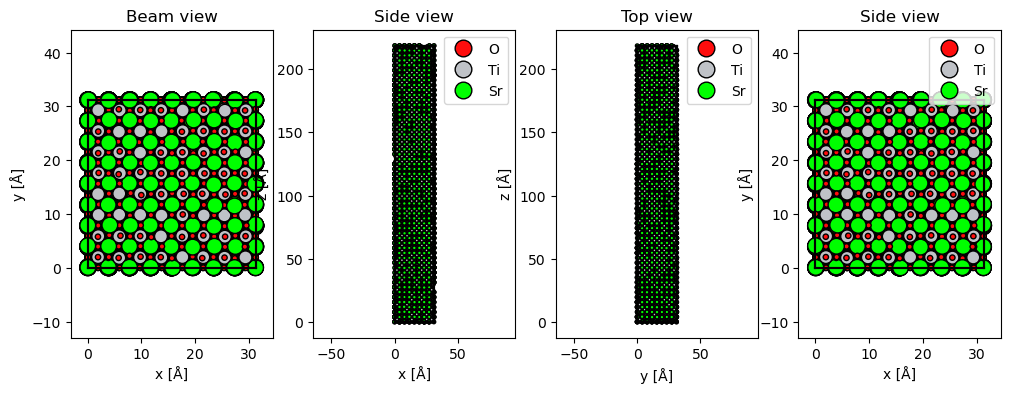

In [3]:
# atoms = ase.build.mx2("WS2", vacuum=2)

# atoms = abtem.orthogonalize_cell(atoms)

# atoms = atoms * (9, 5, 1)
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1"
import glob
from ase.io import read, write
from matplotlib import pyplot as plt
import abtem
import os

snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))
snapshot = snapshots[0]
atoms = read(snapshot, format='lammps-data')

# LAMMPS类型映射: 1=Sr, 2=Ti, 3=O -> 重新映射为正确的原子序数
type_map = {1: 38, 2: 22, 3: 8}  # Sr=38, Ti=22, O=8 (原子序数)
new_numbers = [type_map[num] for num in atoms.numbers]
atoms.set_atomic_numbers(new_numbers)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(atoms, ax=ax3, plane="yz", title="Top view", legend=True);
abtem.show_atoms(atoms, ax=ax4, plane="xy", title="Side view", legend=True);

In [4]:
atoms.cell

Cell([31.24, 31.24, 218.68])

In [14]:
# 使用lammps轨迹进行计算
import glob
from ase.io import read
import abtem
import os

# run lammps
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1"

snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))

# LAMMPS类型映射: 1=Sr, 2=Ti, 3=O -> 重新映射为正确的原子序数
type_map = {1: 38, 2: 22, 3: 8}  # Sr=38, Ti=22, O=8 (原子序数)


flexible_measurements = []
for snapshot in snapshots[:10]:
    print(snapshot)
    if snapshot.endswith('snapshot_avg.lammps'):
        print(f"skip {snapshot}")   
        continue
    atoms = read(snapshot, format='lammps-data')
    
    # 重新映射原子类型
    new_numbers = [type_map[num] for num in atoms.numbers]
    atoms.set_atomic_numbers(new_numbers)
    
    # 计算势场
    lammps_phonons = abtem.FrozenPhonons(atoms, 1, sigmas={'Sr': 0.0, 'Ti': 0.0, 'O': 0.0})
    potential = abtem.Potential(lammps_phonons, sampling=0.05)

    # 创建探针
    probe = abtem.Probe(energy=300e3, extent=0, semiangle_cutoff=25, Cs=0, defocus=0)
    probe.grid.match(potential)

    # 扫描区域
    grid_scan = abtem.GridScan(
        start=(0,0),
        end=(0.25, 0.25),
        sampling=probe.aperture.nyquist_sampling,
        fractional=True,
        potential=potential,
    )


    # 检测器
    detector = abtem.SegmentedDetector(4,4,7,28)
    #detector = abtem.FlexibleAnnularDetector()

    # 扫描和检测
    flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)
    flexible_measurement.compute()
    flexible_measurements.append(flexible_measurement)

/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_503.lammps
[########################################] | 100% Completed | 83.52 s
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_534.lammps
[########################################] | 100% Completed | 84.92 s
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_565.lammps
[########################################] | 100% Completed | 84.38 s
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_596.lammps
[########################################] | 100% Completed | 82.14 s
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_627.lammps
[########################################] | 100% Completed | 82.83 s
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/data/Perovskite_oxides-PBEsol/SrTiO3/deepMD_1/snap1/snap_6

10
(40, 40)


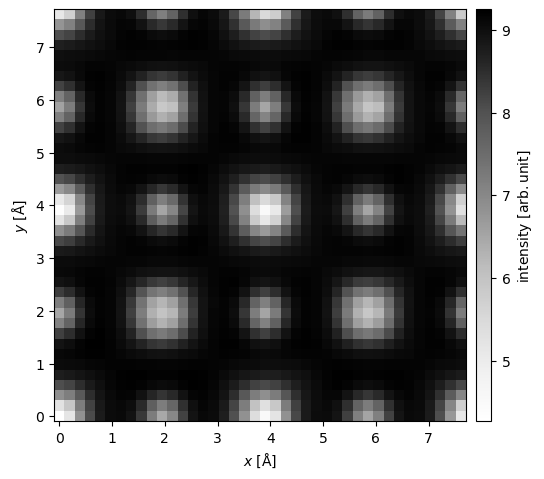

In [15]:
flexible_measurement = flexible_measurements[0]
l = len(flexible_measurements)
print(l)
for i in range(1, l):
    flexible_measurement = flexible_measurement + flexible_measurements[i]
idpc = flexible_measurement.integrate()
print(idpc.shape)
idpc.show(cbar=True, cmap='Grays');

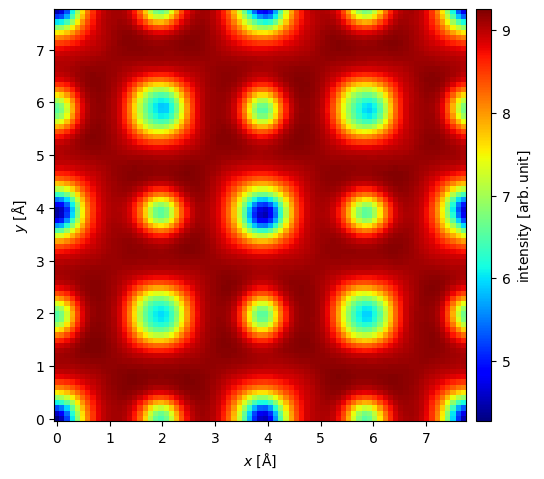

In [16]:
interpolated_measurements = idpc.interpolate(0.1)
interpolated_measurements = interpolated_measurements.tile((1,1))
interpolated_measurements.show(cbar=True, cmap='jet')

In [222]:
atoms.cell

Cell([[0.0, 0.0, -124.0359570206], [-31.0089892552, 0.0, 0.0], [0.0, 34.2568024821, 0.0]])

In [221]:
atoms.cell-average_atoms.cell

array([[ 0.00000000e+00,  0.00000000e+00, -2.05999982e-08],
       [-2.55200000e-07,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.82099999e-07,  0.00000000e+00]])

In [218]:
average_atoms.cell

Cell([[0.0, 0.0, -124.035957], [-31.008989, 0.0, 0.0], [0.0, 34.256802, 0.0]])

In [211]:
# 检查原子类型
print("原子符号:", set(average_atoms.get_chemical_symbols()))
print("原子序数:", set(average_atoms.get_atomic_numbers()))
print("化学式:", average_atoms.get_chemical_formula())

原子符号: {'Ti', 'Pb', 'O'}
原子序数: {8, 82, 22}
化学式: O6144Pb2048Ti2048


In [190]:
# ========== 保存结果的多种方法 ==========

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 查看对象的属性
print("对象类型:", type(fp_idpc))
print("数组形状:", fp_idpc.shape)
print("数组dtype:", fp_idpc.array.dtype)
print("数据范围: [{:.4f}, {:.4f}]".format(fp_idpc.array.min(), fp_idpc.array.max()))

# 2. 获取数据
data = fp_idpc.array
print("原始数据形状:", data.shape)

# 3. 保存为PNG（使用matplotlib）
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data.get(), cmap='jet')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('idpc_result.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 已保存为 idpc_result.png")

# 4. 保存为TIFF（使用tifffile处理多维数据）
try:
    import tifffile
    # 如果是多维数据，保存原始数据
    tifffile.imwrite('idpc_result.tiff', data.get().astype(np.float32))
    print("✓ 已保存为 idpc_result.tiff (float32 格式)")
except ImportError:
    # 如果没有tifffile，用PIL保存2D切片
    if data.ndim > 2:
        # 取第一个切片
        data_2d = data[0] if data.ndim == 3 else data
    else:
        data_2d = data
    
    # 归一化到0-255
    data_normalized = ((data_2d - data_2d.min()) / (data_2d.max() - data_2d.min()) * 255).astype(np.uint8)
    Image.fromarray(data_normalized).save('idpc_result_slice.tiff')
    print("✓ 已保存为 idpc_result_slice.tiff (第一个切片, uint8 格式)")

# 5. 保存为Numpy数组（.npy格式）- 推荐用于原始数据
np.save('idpc_data.npy', data)
print("✓ 已保存为 idpc_data.npy (原始数据)")

# 6. 保存为HDF5（推荐用于元数据）
try:
    import h5py
    with h5py.File('idpc_result.h5', 'w') as f:
        f.create_dataset('data', data=data.get())
        f.attrs['shape'] = data.shape
        f.attrs['dtype'] = str(data.dtype)
    print("✓ 已保存为 idpc_result.h5")
except ImportError:
    print("⚠ 未安装h5py，跳过HDF5保存")

# 7. 为后续分析导出数据
print("\n可用的对象方法:")
available_methods = [m for m in dir(fp_idpc) if not m.startswith('_')]
for method in sorted(available_methods)[:10]:
    print(f"  - {method}")

print("\n✓ 所有数据已保存！")

对象类型: <class 'abtem.measurements.Images'>
数组形状: (40, 44)
数组dtype: float32
数据范围: [0.3131, 0.9105]
原始数据形状: (40, 44)
✓ 已保存为 idpc_result.png
✓ 已保存为 idpc_result.tiff (float32 格式)
✓ 已保存为 idpc_data.npy (原始数据)
✓ 已保存为 idpc_result.h5

可用的对象方法:
  - abs
  - apply_func
  - apply_transform
  - array
  - axes_metadata
  - base_axes_metadata
  - base_dims
  - base_shape
  - compute
  - coordinates

✓ 所有数据已保存！


<HDF5 dataset "data": shape (40, 44), type "<f4">


array([[0.8236355 , 0.85299814, 0.8144537 , ..., 0.3764727 , 0.55449736,
        0.73803586],
       [0.8299588 , 0.8602354 , 0.83554125, ..., 0.44377077, 0.60953766,
        0.7619379 ],
       [0.8469933 , 0.87435293, 0.87098354, ..., 0.6180058 , 0.7228436 ,
        0.8067022 ],
       ...,
       [0.8664483 , 0.88353705, 0.8876883 , ..., 0.76000094, 0.7988514 ,
        0.836537  ],
       [0.84937906, 0.87139803, 0.86589485, ..., 0.61721873, 0.71167874,
        0.7972989 ],
       [0.83205163, 0.8559099 , 0.8289559 , ..., 0.45646334, 0.60508484,
        0.75217265]], dtype=float32)

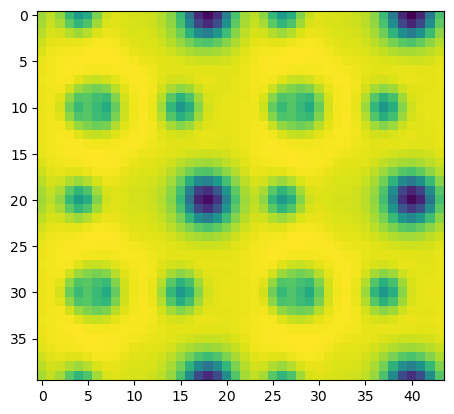

In [207]:
import h5py
h5_file = "/media/chenguisen/WD_BLACK/AISI/imagesimulation/doc/docs/user_guide/examples/notebooks/idpc_result.h5"
data = h5py.File(h5_file, 'r')
d = data['data']
print(d)
import matplotlib.pyplot as plt
plt.imshow(d)
d[:,:]